# Library import

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.ensemble import ExtraTreesClassifier, AdaBoostClassifier, HistGradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import mutual_info_classif, SelectFromModel
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import KFold, train_test_split, cross_val_score, cross_val_predict
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    StratifiedKFold,                                 
    learning_curve
)

import warnings

from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import classification_report, confusion_matrix
from lightgbm import LGBMClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from optuna.samplers import TPESampler


warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# EDA

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/noctican/10-MuhammadArsyadSetiawan-CandraAndikaPutra/refs/heads/main/ai_worker_burnout_attrition_2026.csv')
df

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,EMP1496,Frontend Engineer,2,Master,Brazil,Fintech,Enterprise (5000+),Hybrid,36,47,...,7,6.9,69,Integrating,2.6,74,63,3.1,High,Medium
1496,EMP1497,Prompt Engineer,1,PhD,UK,E-commerce,Small (50-200),Hybrid,22,199,...,1,1.2,7,Integrating,6.9,39,25,3.5,Low,Low
1497,EMP1498,Backend Engineer,8,Bachelor,Canada,Cybersecurity,Mid (200-1000),Hybrid,48,120,...,3,6.8,73,Optimizing,4.0,44,65,2.9,High,High
1498,EMP1499,AI Ethics Officer,13,Self-taught,Netherlands,Media,Startup (<50),Fully Remote,41,208,...,6,3.2,68,Optimizing,4.1,77,53,2.8,Low,Medium


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   object 
 1   job_role                        1500 non-null   object 
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   object 
 4   country                         1500 non-null   object 
 5   industry                        1500 non-null   object 
 6   company_size                    1500 non-null   object 
 7   remote_work_type                1500 non-null   object 
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   object 
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  15

In [4]:
df.isna().sum()

employee_id                       0
job_role                          0
years_experience                  0
education_level                   0
country                           0
industry                          0
company_size                      0
remote_work_type                  0
team_size                         0
salary_usd_k                      0
primary_ai_tool                   0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
ai_adoption_stage                 0
weekly_ai_upskilling_hrs          0
productivity_score                0
burnout_score                     0
job_satisfaction_1_5              0
fear_of_ai_replacement            0
attrition_risk                    0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## 1. Hubungan peluang reisgn dan level penerapan AI

In [6]:
df.value_counts(['ai_adoption_stage','attrition_risk']).unstack()

attrition_risk,High,Low,Medium
ai_adoption_stage,,,
AI-First,16,120,114
Experimenting,20,184,154
Integrating,25,232,235
Optimizing,24,188,188


In [7]:
table = df.value_counts(['ai_adoption_stage','attrition_risk']).unstack()
percent_table = (table.div(table.sum(axis=1), axis=0) * 100).round(2)
percent_table

attrition_risk,High,Low,Medium
ai_adoption_stage,,,
AI-First,6.40,48.00,45.60
Experimenting,5.59,51.40,43.02
Integrating,5.08,47.15,47.76
Optimizing,6.00,47.00,47.00


## 2. Rata Rata setiap feature numerik dengan peluang resign karyawan

In [8]:
df.groupby('attrition_risk')[[
    'salary_usd_k',
    'years_experience',
    'ai_tools_used_per_day',
    'hours_with_ai_assistance_daily',
    'ai_replaces_my_tasks_pct',
    'weekly_ai_upskilling_hrs',
    'productivity_score',
    'job_satisfaction_1_5',
    'burnout_score'
]].mean()

,salary_usd_k,years_experience,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,productivity_score,job_satisfaction_1_5,burnout_score
attrition_risk,,,,,,,,,
High,138.564706,10.094118,3.576471,5.111765,56.647059,5.130588,55.929412,2.657647,60.80000
Low,140.513812,10.040055,4.035912,3.830249,33.493094,4.964641,57.600829,3.687431,44.03453
Medium,141.231548,9.832127,4.136035,4.548480,47.480463,4.989580,57.681621,3.048480,55.04631


## 3. Distribusi level penerapan AI

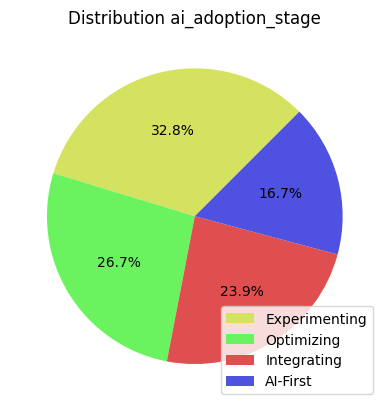

In [9]:
custom_colors = ["#d5e260", "#6bf35f", "#e04f4f", "#4f51e0"]

label = df["ai_adoption_stage"].unique()
size = df["ai_adoption_stage"].value_counts()

plt.pie(size, autopct="%1.1f%%", startangle=45, colors=custom_colors)
plt.title("Distribution ai_adoption_stage")
plt.legend(label)

## 4. Hubungan resiko resign dengan lama waktu penggunaan AI per harinya

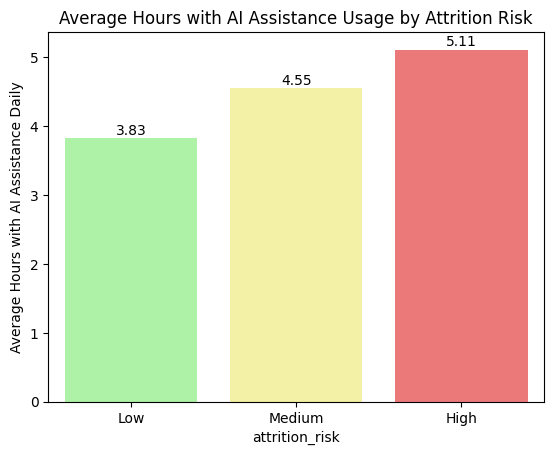

In [10]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]
ax = sns.barplot(x='attrition_risk', y='hours_with_ai_assistance_daily', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("attrition_risk")
plt.title("Average Hours with AI Assistance Usage by Attrition Risk")
plt.show()


## 5. Hubungan Lama penggunaan AI, dengan ketakutan pekerjaan digantikan oleh AI

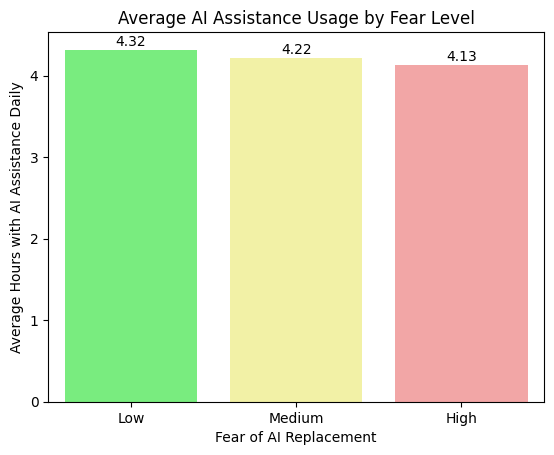

In [11]:
custom_colors = ["#66ff6e", "#fffd99", "#ff9999"]
ax = sns.barplot(
    x='fear_of_ai_replacement',
    y='hours_with_ai_assistance_daily',
    data=df,
    palette=custom_colors,
    errorbar=None

)

# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Hours with AI Assistance Daily")
plt.xlabel("Fear of AI Replacement")
plt.title("Average AI Assistance Usage by Fear Level")
plt.show()

## 6. Persebaran burnout score dengan lama waktu penggunaan AI perharinya

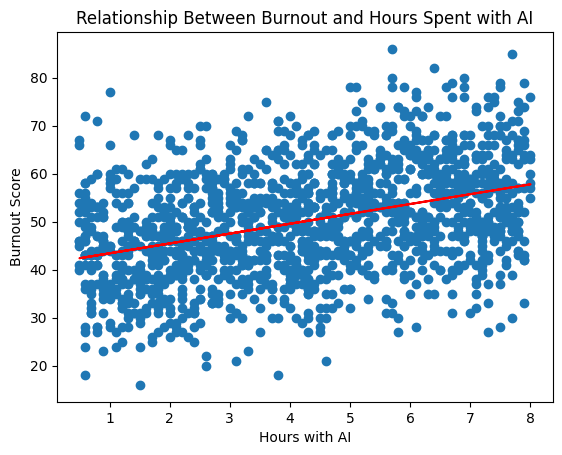

In [12]:
y = df['burnout_score']
x = df['hours_with_ai_assistance_daily']

plt.scatter(x, y,  cmap='viridis', alpha=1)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("Hours with AI")

# judul (opsional)
plt.title("Relationship Between Burnout and Hours Spent with AI")

plt.show()

## 7. Hubungan resiko resign dengan persentase tugas yang digantikan oleh AI

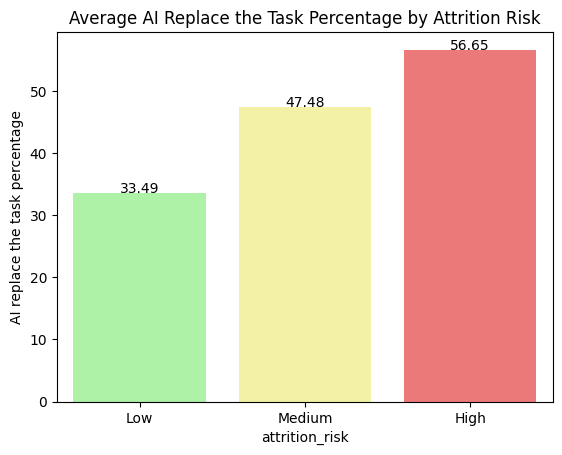

In [13]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]
ax = sns.barplot(x='attrition_risk', y='ai_replaces_my_tasks_pct', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("AI replace the task percentage")
plt.xlabel("attrition_risk")
plt.title("Average AI Replace the Task Percentage by Attrition Risk")
plt.show()


## 8. Hubungan persebaran persentase tugas yang digantikan oleh AI dengan burnout score

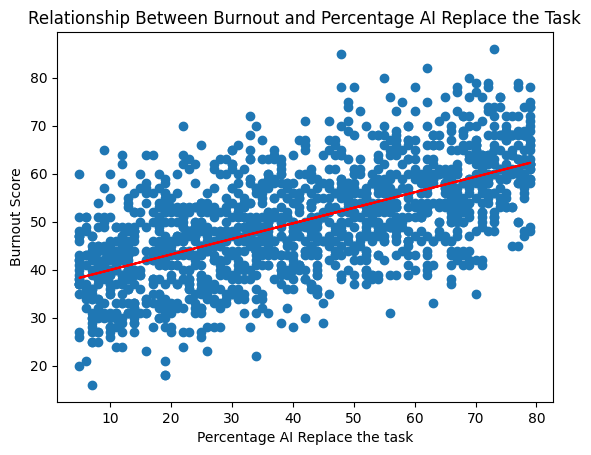

In [14]:
y = df['burnout_score']
x = df['ai_replaces_my_tasks_pct']

plt.scatter(x, y,  cmap='viridis', alpha=1)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Burnout Score")
plt.xlabel("Percentage AI Replace the task")

# judul (opsional)
plt.title("Relationship Between Burnout and Percentage AI Replace the Task")

plt.show()

## 9. Hubungan resiko resign dari perusahaan dengan kepuasan bekerja karyawan

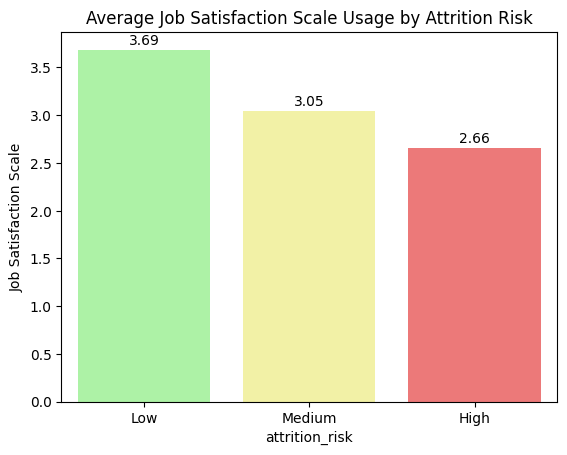

In [15]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]
ax = sns.barplot(x='attrition_risk', y='job_satisfaction_1_5', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Job Satisfaction Scale")
plt.xlabel("attrition_risk")
plt.title("Average Job Satisfaction Scale Usage by Attrition Risk")
plt.show()


## 10. Jumlah ketakutan tergantikan oleh AI berdasarkan resiko resign

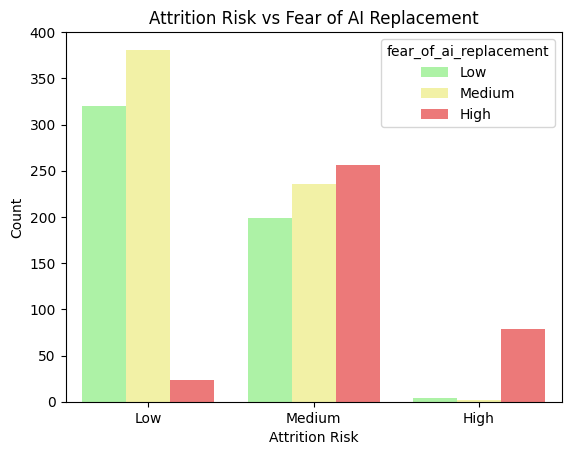

In [16]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]

sns.countplot(
    x='attrition_risk',
    hue='fear_of_ai_replacement',
    data=df,
    palette=custom_colors,
    order=['Low', 'Medium', 'High']

)

plt.title("Attrition Risk vs Fear of AI Replacement")
plt.xlabel("Attrition Risk")
plt.ylabel("Count")
plt.show()

## 11. Hubungan burnout score dengan resiko resign

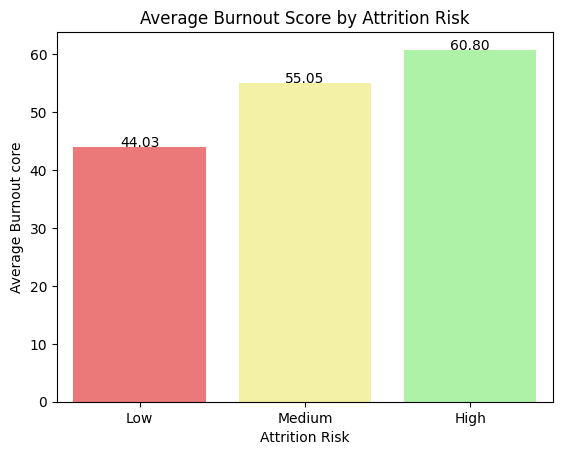

In [17]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='attrition_risk', y='burnout_score', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Average Burnout core")
plt.xlabel("Attrition Risk")
plt.title("Average Burnout Score by Attrition Risk")
plt.show()


## 12. Hubungan Rata rata gaji pekerja dengan resiko resign

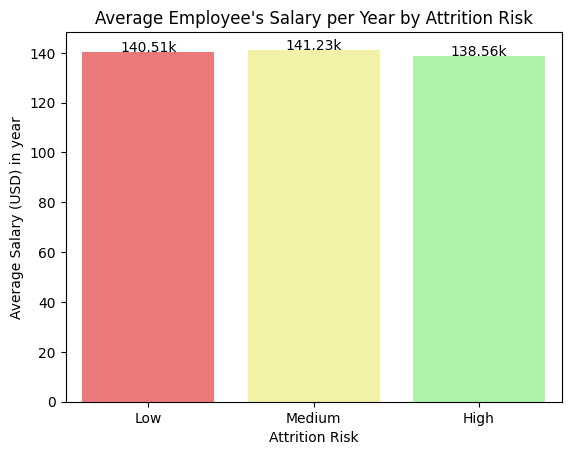

In [18]:

custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
ax = sns.barplot(x='attrition_risk', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
# menampilkan nilai mean di atas bar
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Attrition Risk")
plt.title("Average Employee's Salary per Year by Attrition Risk")
plt.show()


## 13. Hubungan persebaran Year Experience dengan banyaknya Gaji

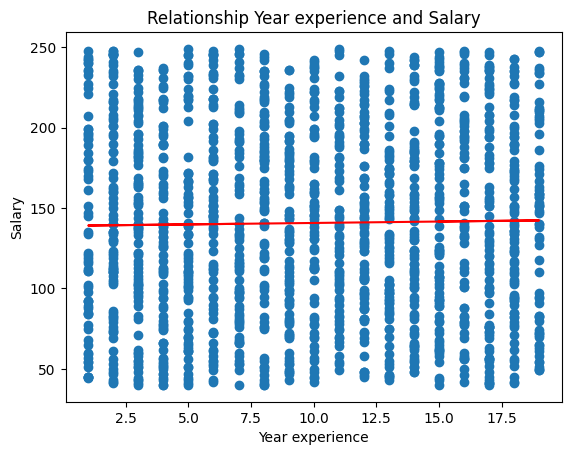

In [19]:
x = df['years_experience']
y = df['salary_usd_k']

plt.scatter(x, y,  cmap='viridis', alpha=1)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Salary")
plt.xlabel("Year experience")

# judul (opsional)
plt.title("Relationship Year experience and Salary")

plt.show()

## 14. Rata rata gaji karywan per job role

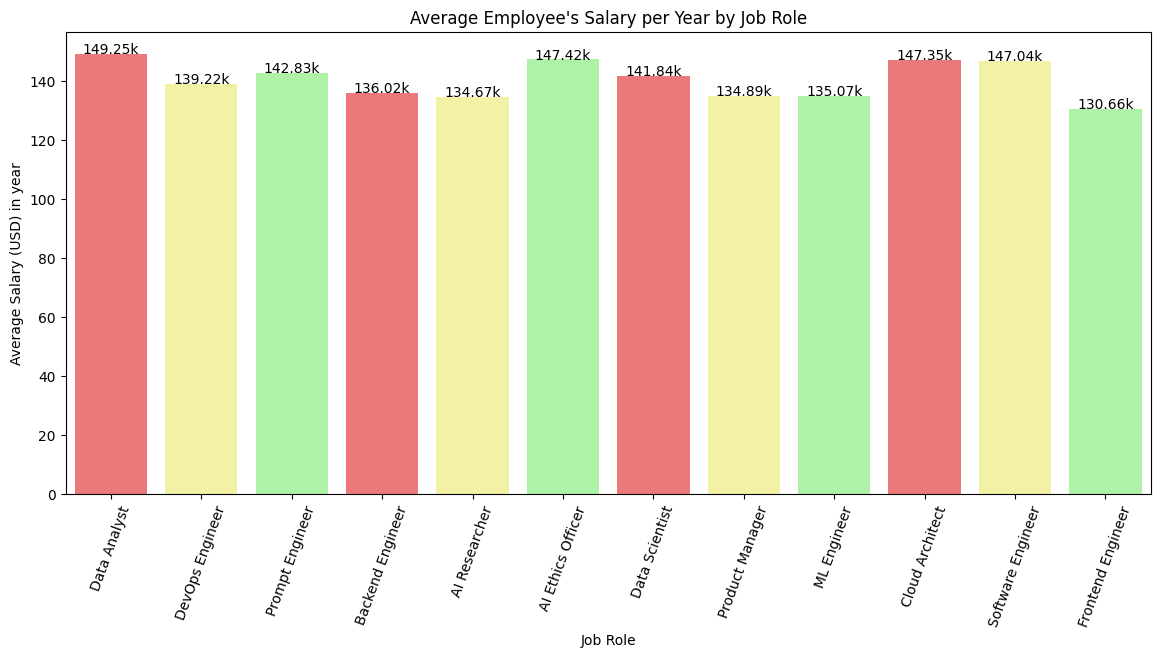

In [20]:
custom_colors = ["#ff6666", "#fffd99", "#a2ff99"]
plt.figure(figsize=(14,6))
ax = sns.barplot(x='job_role', y='salary_usd_k', data=df, palette=custom_colors, errorbar=None)

for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}k",
        ha='center'
    )

plt.ylabel("Average Salary (USD) in year")
plt.xlabel("Job Role")
plt.title("Average Employee's Salary per Year by Job Role")
plt.xticks(rotation=70)
plt.show()


## 15. Hubungan lama waktu bekerja dengan resiko resign

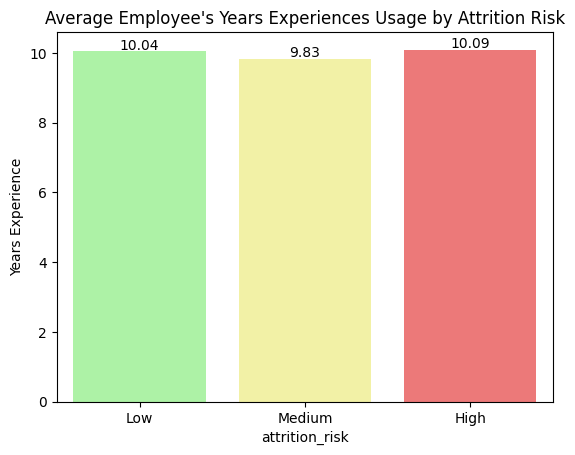

In [21]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]
ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("Years Experience")
plt.xlabel("attrition_risk")
plt.title("Average Employee's Years Experiences Usage by Attrition Risk")
plt.show()


## 16. Job Role dengan persentase tugas yang tergantikan oleh AI

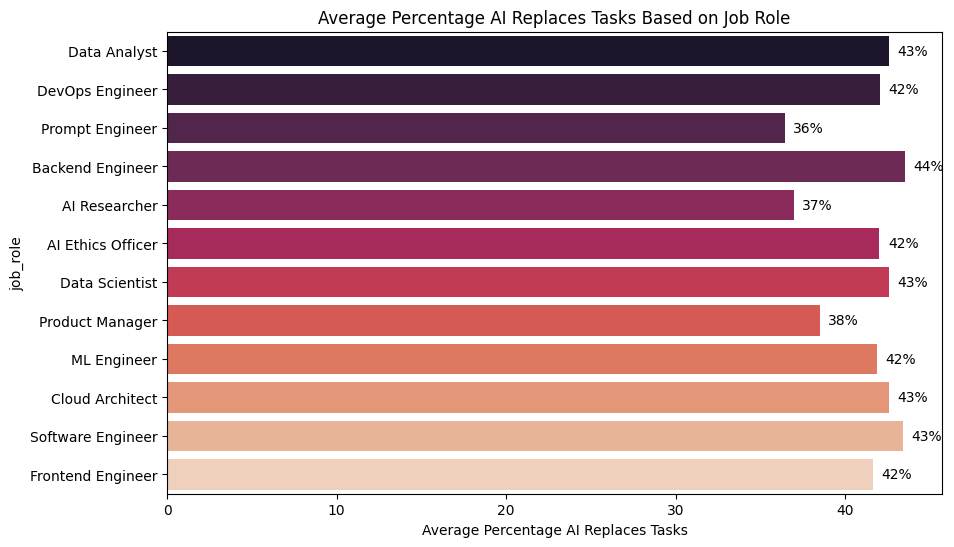

In [22]:
plt.figure(figsize=(10,6))
ax = sns.barplot(x='ai_replaces_my_tasks_pct', y='job_role', data=df, palette="rocket", errorbar=None)
# menampilkan nilai mean di atas bar
for p in ax.patches:
    # Untuk bar horizontal:
    # width = nilai (sumbu x)
    # y = posisi bar (sumbu y)
    width = p.get_width() 
    
    ax.text(
        width + 0.5,                # Posisi X: sedikit di kanan ujung bar
        p.get_y() + p.get_height()/2, # Posisi Y: tepat di tengah ketebalan bar
        f'{width:.0f}%',          # Format teks
        va='center'               # Alignment vertikal agar presisi di tengah
    )

plt.xlabel("Average Percentage AI Replaces Tasks")

plt.title("Average Percentage AI Replaces Tasks Based on Job Role")
plt.show()


## 17. Hubungan dengan lama waktu penggunaan bersama AI dengan score produktivitas

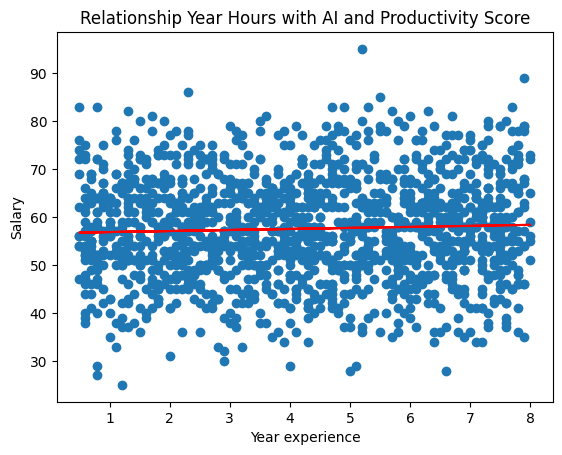

In [23]:
x = df['hours_with_ai_assistance_daily']
y = df['productivity_score']

plt.scatter(x, y,  cmap='viridis', alpha=1)

# membuat garis regresi linear
m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='red')

# label sumbu
plt.ylabel("Salary")
plt.xlabel("Year experience")

# judul (opsional)
plt.title("Relationship Year Hours with AI and Productivity Score")

plt.show()

## 18. Hubungan produktivitas dengan resiko resign

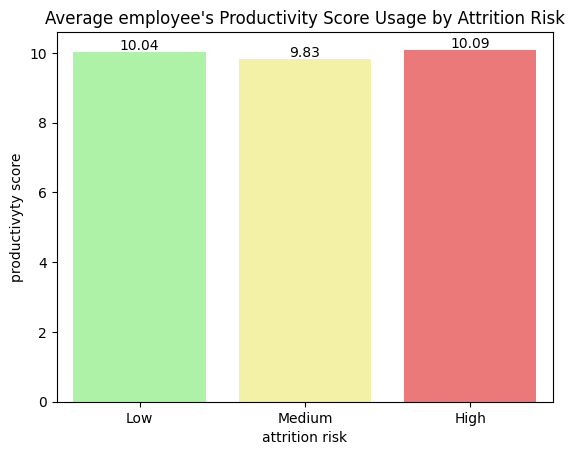

In [24]:
custom_colors = ["#a2ff99", "#fffd99", "#ff6666"]
ax = sns.barplot(x='attrition_risk', y='years_experience', data=df, palette=custom_colors, errorbar=None, order=['Low', 'Medium', 'High'])
for p in ax.patches:
    mean_value = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        mean_value + 0.05,
        f"{mean_value:.2f}",
        ha='center'
    )

plt.ylabel("productivyty score")
plt.xlabel("attrition risk")
plt.title("Average employee's Productivity Score Usage by Attrition Risk")
plt.show()


## Relasi Hubungan fitur kategorikal dengan kolom attrittion_risk

In [25]:
categorical_col = df.select_dtypes('object')
categorical_col.columns

Index(['employee_id', 'job_role', 'education_level', 'country', 'industry',
       'company_size', 'remote_work_type', 'primary_ai_tool',
       'ai_adoption_stage', 'fear_of_ai_replacement', 'attrition_risk'],
      dtype='object')

In [26]:
categorical_col = categorical_col.drop(columns=['employee_id', 'attrition_risk'])

In [27]:
categorical_feature_relation_list = []

# encode target (wajib untuk MI)
y = df['attrition_risk'].astype('category').cat.codes

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

for col in categorical_col:
    contingency_table = pd.crosstab(df[col], df['attrition_risk'])
    
    # Chi-square
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    # Cramer's V
    cramers_v_value = cramers_v(contingency_table)
    
    # Mutual Information (per kolom)
    X_col = df[[col]].astype('category').apply(lambda x: x.cat.codes)
    mi = mutual_info_classif(X_col, y, discrete_features=True)[0]
    
    categorical_feature_relation_list.append({
        'Column': col,
        'Chi Square': chi2,
        'P-value': p,
        'Cramers V': cramers_v_value,
        'Mutual Information': mi
    })
    print('='*32)
    print(contingency_table)
    print('='*32)

categorical_feature_relation_df = pd.DataFrame(categorical_feature_relation_list)

attrition_risk     High  Low  Medium
job_role                            
AI Ethics Officer    13   66      53
AI Researcher         7   59      69
Backend Engineer      9   60      58
Cloud Architect       6   67      57
Data Analyst          7   55      60
Data Scientist        3   62      70
DevOps Engineer       9   58      49
Frontend Engineer     7   62      47
ML Engineer           6   48      55
Product Manager       4   67      52
Prompt Engineer       6   53      46
Software Engineer     8   67      75
attrition_risk   High  Low  Medium
education_level                   
Bachelor           20  157     137
Bootcamp           12  143     129
Master             19  157     147
PhD                14  141     139
Self-taught        20  126     139
attrition_risk  High  Low  Medium
country                          
Australia         10   81      56
Brazil             7   64      64
Canada             8   75      68
France             7   89      82
Germany            9   69      72

In [28]:
categorical_feature_relation_df

,Column,Chi Square,P-value,Cramers V,Mutual Information
0,job_role,19.620533,6.067629e-01,0.080871,0.006615
1,education_level,5.118446,7.448447e-01,0.041306,0.001730
2,country,12.456062,8.228206e-01,0.064436,0.004211
3,industry,12.607587,8.143377e-01,0.064827,0.004213
4,company_size,4.176177,8.408885e-01,0.037310,0.001427
5,remote_work_type,3.242254,5.181334e-01,0.032875,0.001089
6,primary_ai_tool,7.741583,9.023497e-01,0.050799,0.002515
7,ai_adoption_stage,2.724734,8.425172e-01,0.030137,0.000908
8,fear_of_ai_replacement,459.938144,3.084998e-98,0.391552,0.163782


## Mutual Information kolom numerik dan target

In [29]:
numerical_cols = df.select_dtypes('number').columns
numerical_cols

Index(['years_experience', 'team_size', 'salary_usd_k',
       'ai_tools_used_per_day', 'hours_with_ai_assistance_daily',
       'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs',
       'productivity_score', 'burnout_score', 'job_satisfaction_1_5'],
      dtype='object')

In [30]:
X = df[numerical_cols]
y = df['attrition_risk'].astype('category').cat.codes

mi = mutual_info_classif(X, y)

mi_df = pd.DataFrame({
    'Feature': numerical_cols,
    'Mutual Information': mi
}).sort_values(by='Mutual Information', ascending=False)

In [31]:
mi_df

,Feature,Mutual Information
9,job_satisfaction_1_5,0.195720
8,burnout_score,0.189885
5,ai_replaces_my_tasks_pct,0.092168
3,ai_tools_used_per_day,0.005670
2,salary_usd_k,0.003555
7,productivity_score,0.000834
4,hours_with_ai_assistance_daily,0.000315
0,years_experience,0.000000
1,team_size,0.000000
6,weekly_ai_upskilling_hrs,0.000000


## Korelasi pearson kolom numerikal

<Axes: >

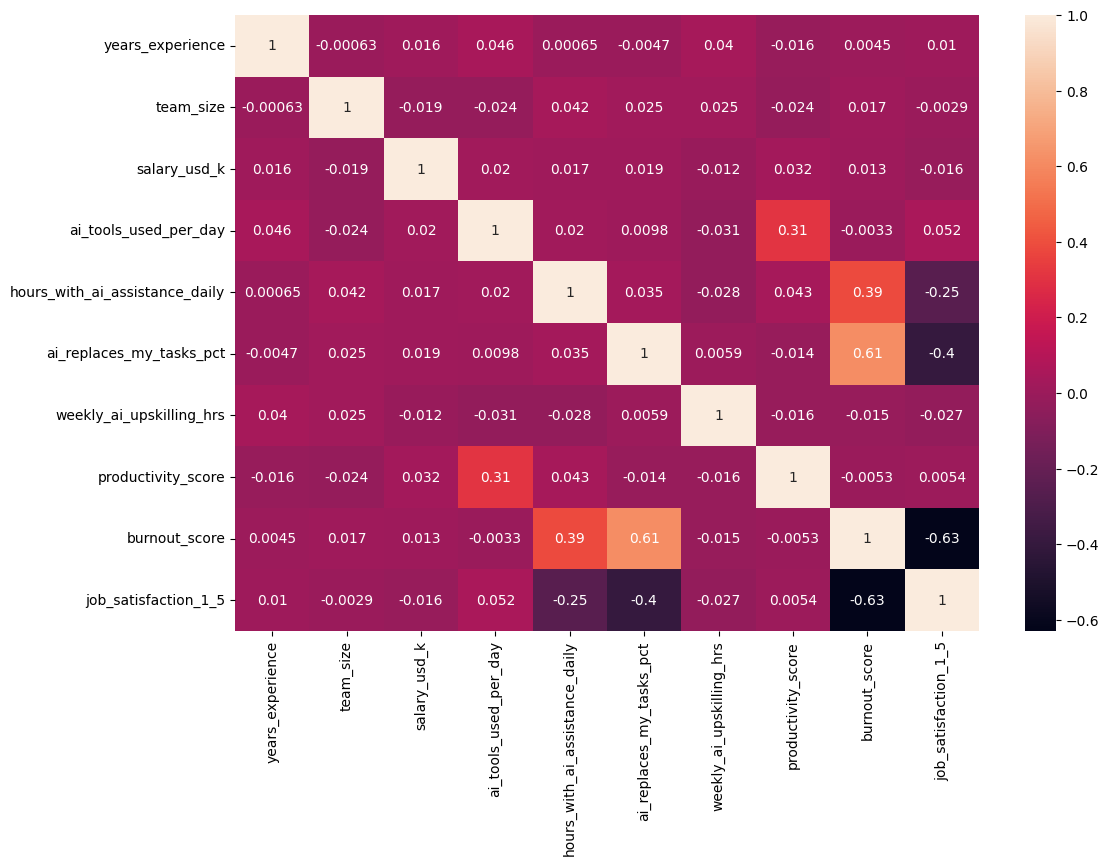

In [32]:
numerical_col = df.select_dtypes('number')

corr = numerical_col.corr()
plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap="rocket")


# Preprocessing

## Removing Unused Columns

In [33]:
df.drop(columns='employee_id', inplace=True)

In [34]:
math_cols = [
    'work_life_balance', 'ai_dependency', 'ai_threat_score', 'upskilling_effort', 
    'productivity_per_ai_hour', 'salary_per_experience', 'burnout_productivity_ratio', 
    'ai_burnout_interaction', 'ai_replace_usage_ratio', 'fear_vs_reality_gap', 
    'burnout_squared', 'log_ai_hours', 'work_pressure', 'learning_ratio', 
    'ai_efficiency', 'ai_replacement_stress', 'salary_to_burnout_ratio', 
    'adaptability_score', 'relative_burnout_industry', 'relative_salary_role'
]

class AddMathFeature(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Tempat untuk menyimpan nilai mean dari training data (mencegah Data Leakage)
        self.industry_burnout_mean_ = {}
        self.role_salary_mean_ = {}
        self.global_burnout_mean_ = 0
        self.global_salary_mean_ = 0

    def fit(self, X, y=None):
        # Menghafal rata-rata (mean) dari data latih SAAT INI
        if 'industry' in X.columns and 'burnout_score' in X.columns:
            self.industry_burnout_mean_ = X.groupby('industry')['burnout_score'].mean().to_dict()
            self.global_burnout_mean_ = X['burnout_score'].mean()
            
        if 'job_role' in X.columns and 'salary_usd_k' in X.columns:
            self.role_salary_mean_ = X.groupby('job_role')['salary_usd_k'].mean().to_dict()
            self.global_salary_mean_ = X['salary_usd_k'].mean()
            
        return self

    def transform(self, X):
        X_new = X.copy()
        
        # 1. Work-Life Balance & Burnout Ratios
        if 'productivity_score' in X_new.columns and 'burnout_score' in X_new.columns:
            X_new['work_life_balance'] = X_new['productivity_score'] - X_new['burnout_score']
            X_new['burnout_productivity_ratio'] = X_new['burnout_score'] / (X_new['productivity_score'] + 1)
            X_new['burnout_squared'] = X_new['burnout_score'] ** 2
            
        # 2. AI Usage & Interactions
        if 'hours_with_ai_assistance_daily' in X_new.columns:
            X_new['log_ai_hours'] = np.log1p(X_new['hours_with_ai_assistance_daily'])
            
            if 'ai_tools_used_per_day' in X_new.columns:
                X_new['ai_dependency'] = X_new['hours_with_ai_assistance_daily'] * X_new['ai_tools_used_per_day']
                
            if 'burnout_score' in X_new.columns:
                X_new['ai_burnout_interaction'] = X_new['hours_with_ai_assistance_daily'] * X_new['burnout_score']
                
            if 'ai_replaces_my_tasks_pct' in X_new.columns:
                X_new['ai_replace_usage_ratio'] = X_new['ai_replaces_my_tasks_pct'] / (X_new['hours_with_ai_assistance_daily'] + 1)
                
            if 'productivity_score' in X_new.columns:
                X_new['productivity_per_ai_hour'] = X_new['productivity_score'] / (X_new['hours_with_ai_assistance_daily'] + 1)

        # 3. Fear & AI Replacement
        if 'ai_replaces_my_tasks_pct' in X_new.columns and 'fear_of_ai_replacement' in X_new.columns:
            fear_map = {'Low': 1, 'Medium': 2, 'High': 3}
            # Mengubah teks ke angka sementara untuk dihitung
            fear_num = X_new['fear_of_ai_replacement'].map(fear_map).fillna(2) # Default ke Medium jika ada data kosong
            X_new['ai_threat_score'] = X_new['ai_replaces_my_tasks_pct'] * fear_num
            X_new['fear_vs_reality_gap'] = fear_num - (X_new['ai_replaces_my_tasks_pct'] / 100)
            
            if 'burnout_score' in X_new.columns:
                X_new['ai_replacement_stress'] = X_new['ai_replaces_my_tasks_pct'] * X_new['burnout_score']
                
        # 4. Upskilling & Learning
        if 'weekly_ai_upskilling_hrs' in X_new.columns:
            if 'years_experience' in X_new.columns:
                X_new['upskilling_effort'] = X_new['weekly_ai_upskilling_hrs'] / (X_new['years_experience'] + 1)
            if 'ai_tools_used_per_day' in X_new.columns:
                X_new['learning_ratio'] = X_new['weekly_ai_upskilling_hrs'] / (X_new['ai_tools_used_per_day'] + 1)
            if 'ai_replaces_my_tasks_pct' in X_new.columns:
                X_new['adaptability_score'] = X_new['weekly_ai_upskilling_hrs'] / (X_new['ai_replaces_my_tasks_pct'] + 1)

        # 5. Salary & Experience
        if 'salary_usd_k' in X_new.columns:
            if 'years_experience' in X_new.columns:
                X_new['salary_per_experience'] = X_new['salary_usd_k'] / (X_new['years_experience'] + 1)
            if 'burnout_score' in X_new.columns:
                X_new['salary_to_burnout_ratio'] = X_new['salary_usd_k'] / (X_new['burnout_score'] + 1)

        # 6. Team & Pressure
        if 'team_size' in X_new.columns and 'burnout_score' in X_new.columns:
            X_new['work_pressure'] = X_new['team_size'] * X_new['burnout_score']
            
        # 7. AI Efficiency (Berdasarkan ai_dependency yang dibuat di atas)
        if 'productivity_score' in X_new.columns and 'ai_dependency' in X_new.columns:
            X_new['ai_efficiency'] = X_new['productivity_score'] / (X_new['ai_dependency'] + 1)

        # 8. Relative Aggregation (Menggunakan nilai hafalan dari .fit())
        if 'industry' in X_new.columns and 'burnout_score' in X_new.columns:
            # Map nilai mean dari dictionary. Kalau industrinya belum pernah ada, pakai global mean.
            ind_mean = X_new['industry'].map(self.industry_burnout_mean_).fillna(self.global_burnout_mean_)
            X_new['relative_burnout_industry'] = X_new['burnout_score'] - ind_mean
            
        if 'job_role' in X_new.columns and 'salary_usd_k' in X_new.columns:
            role_mean = X_new['job_role'].map(self.role_salary_mean_).fillna(self.global_salary_mean_)
            X_new['relative_salary_role'] = X_new['salary_usd_k'] / (role_mean + 1)

        return X_new

math_tunning = AddMathFeature()
df_w_math = df.copy()
df_w_math = math_tunning.fit_transform(df_w_math)

## Normalisasi

In [35]:
def show_distribution(df, cols):
  n_cols = 3
  n_rows = (len(cols) + n_cols - 1) // n_cols

  fig, ax = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
  ax = ax.flatten()

  for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=ax[i])
    ax[i].set_title(f'Distribusi: {col}')
    ax[i].set_xlabel('')
    ax[i].set_ylabel('Frekuensi')

  plt.tight_layout()
  plt.show()

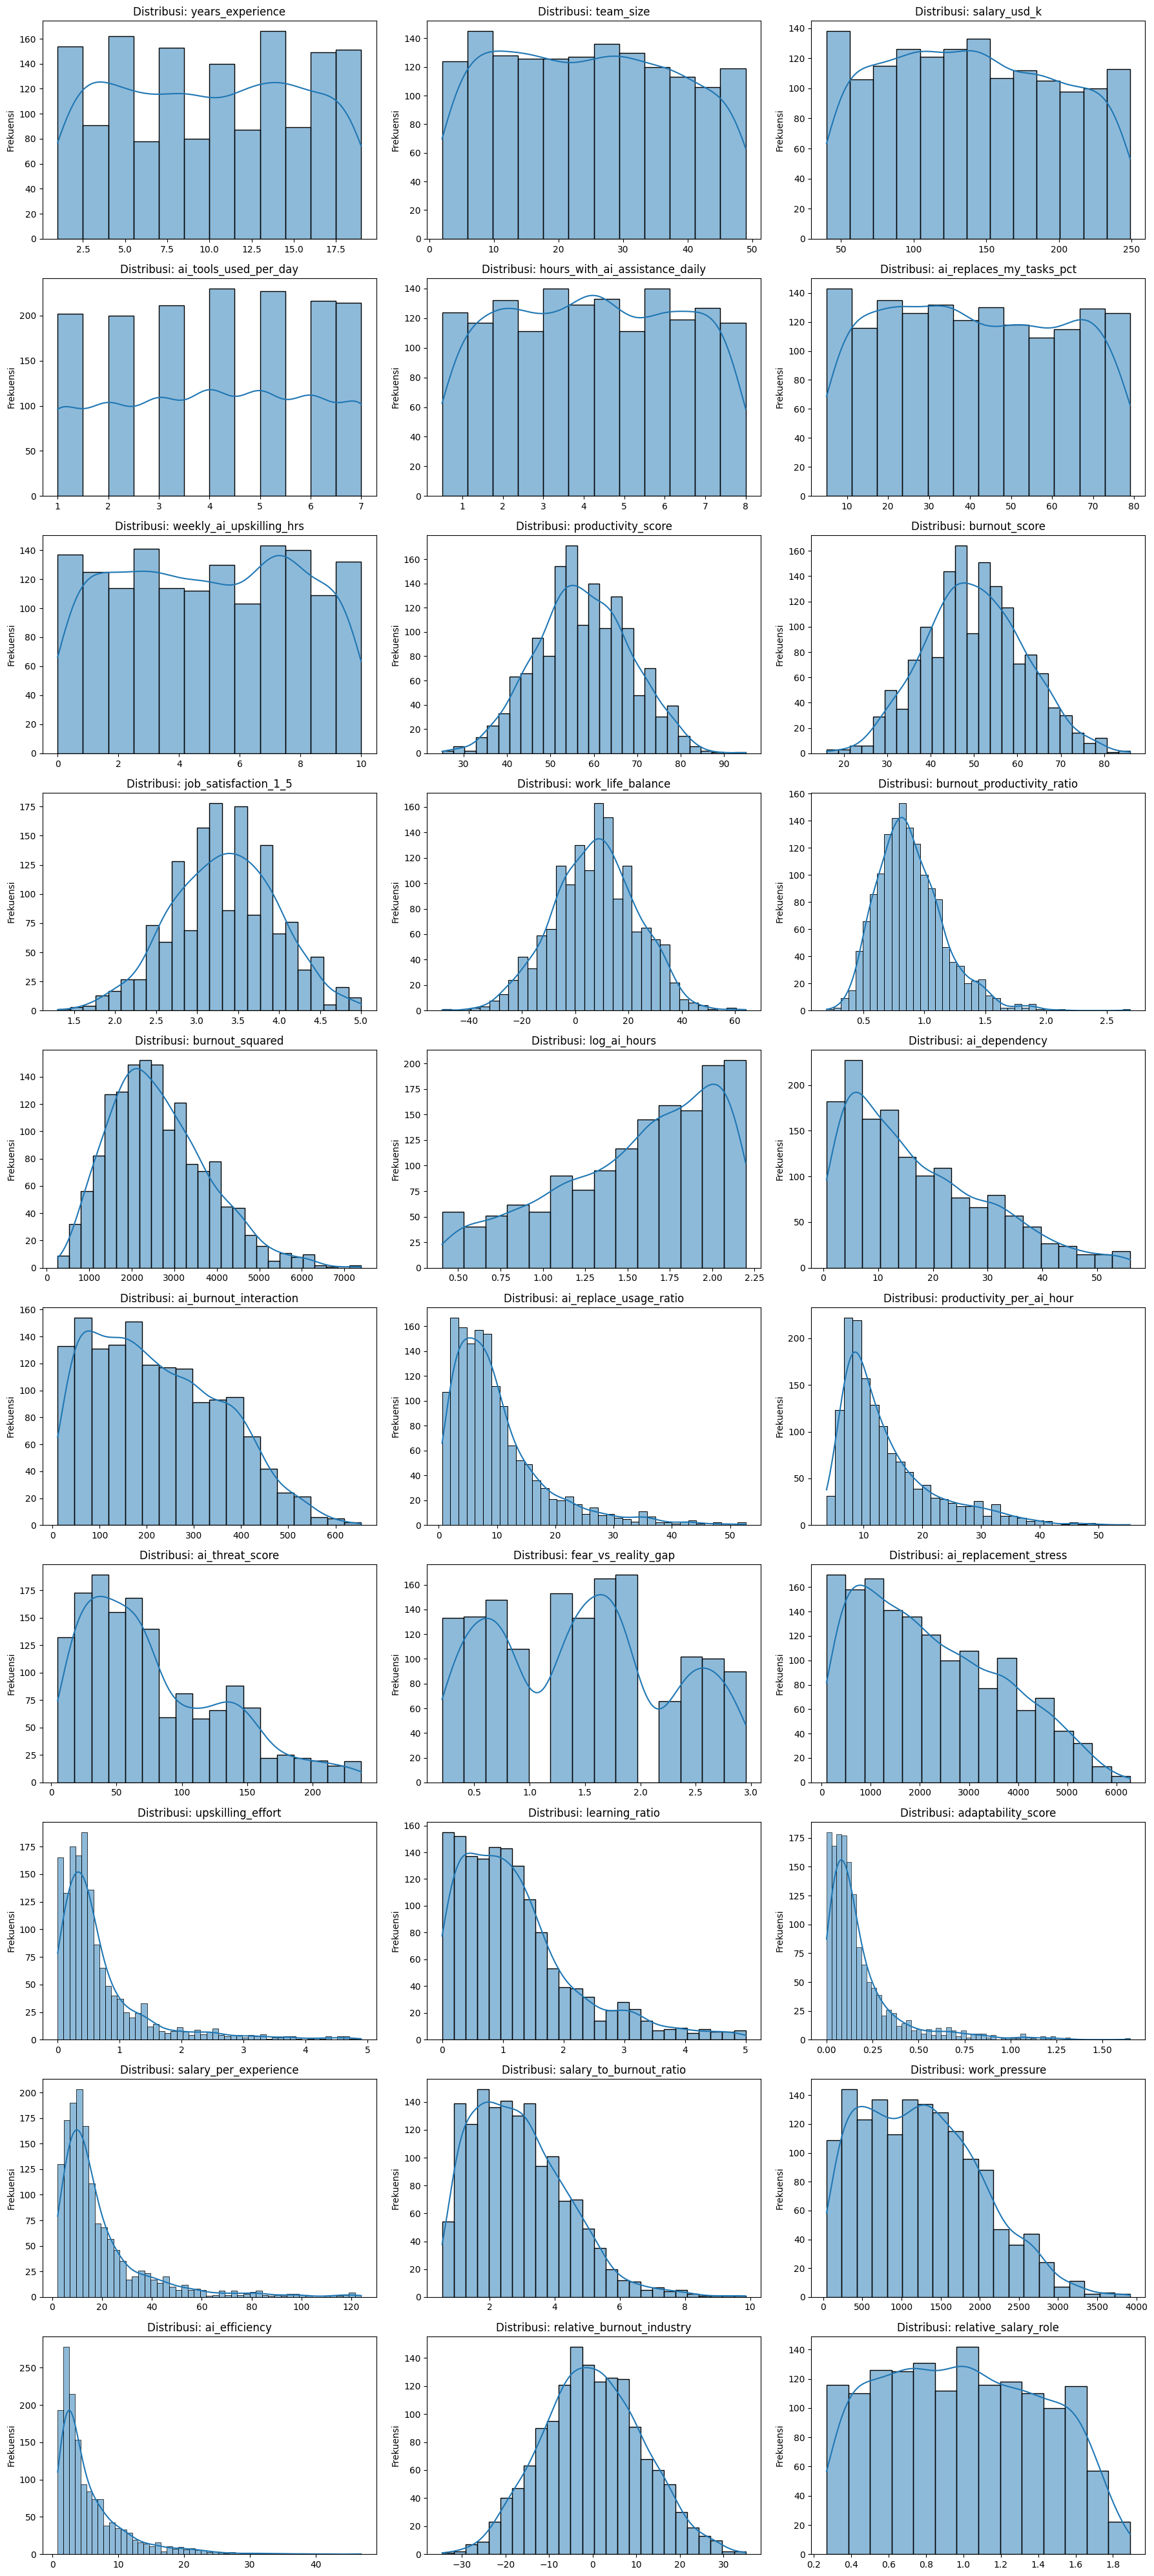

In [36]:
num_cols = df_w_math.select_dtypes(include=['number']).columns
show_distribution(df_w_math, num_cols)

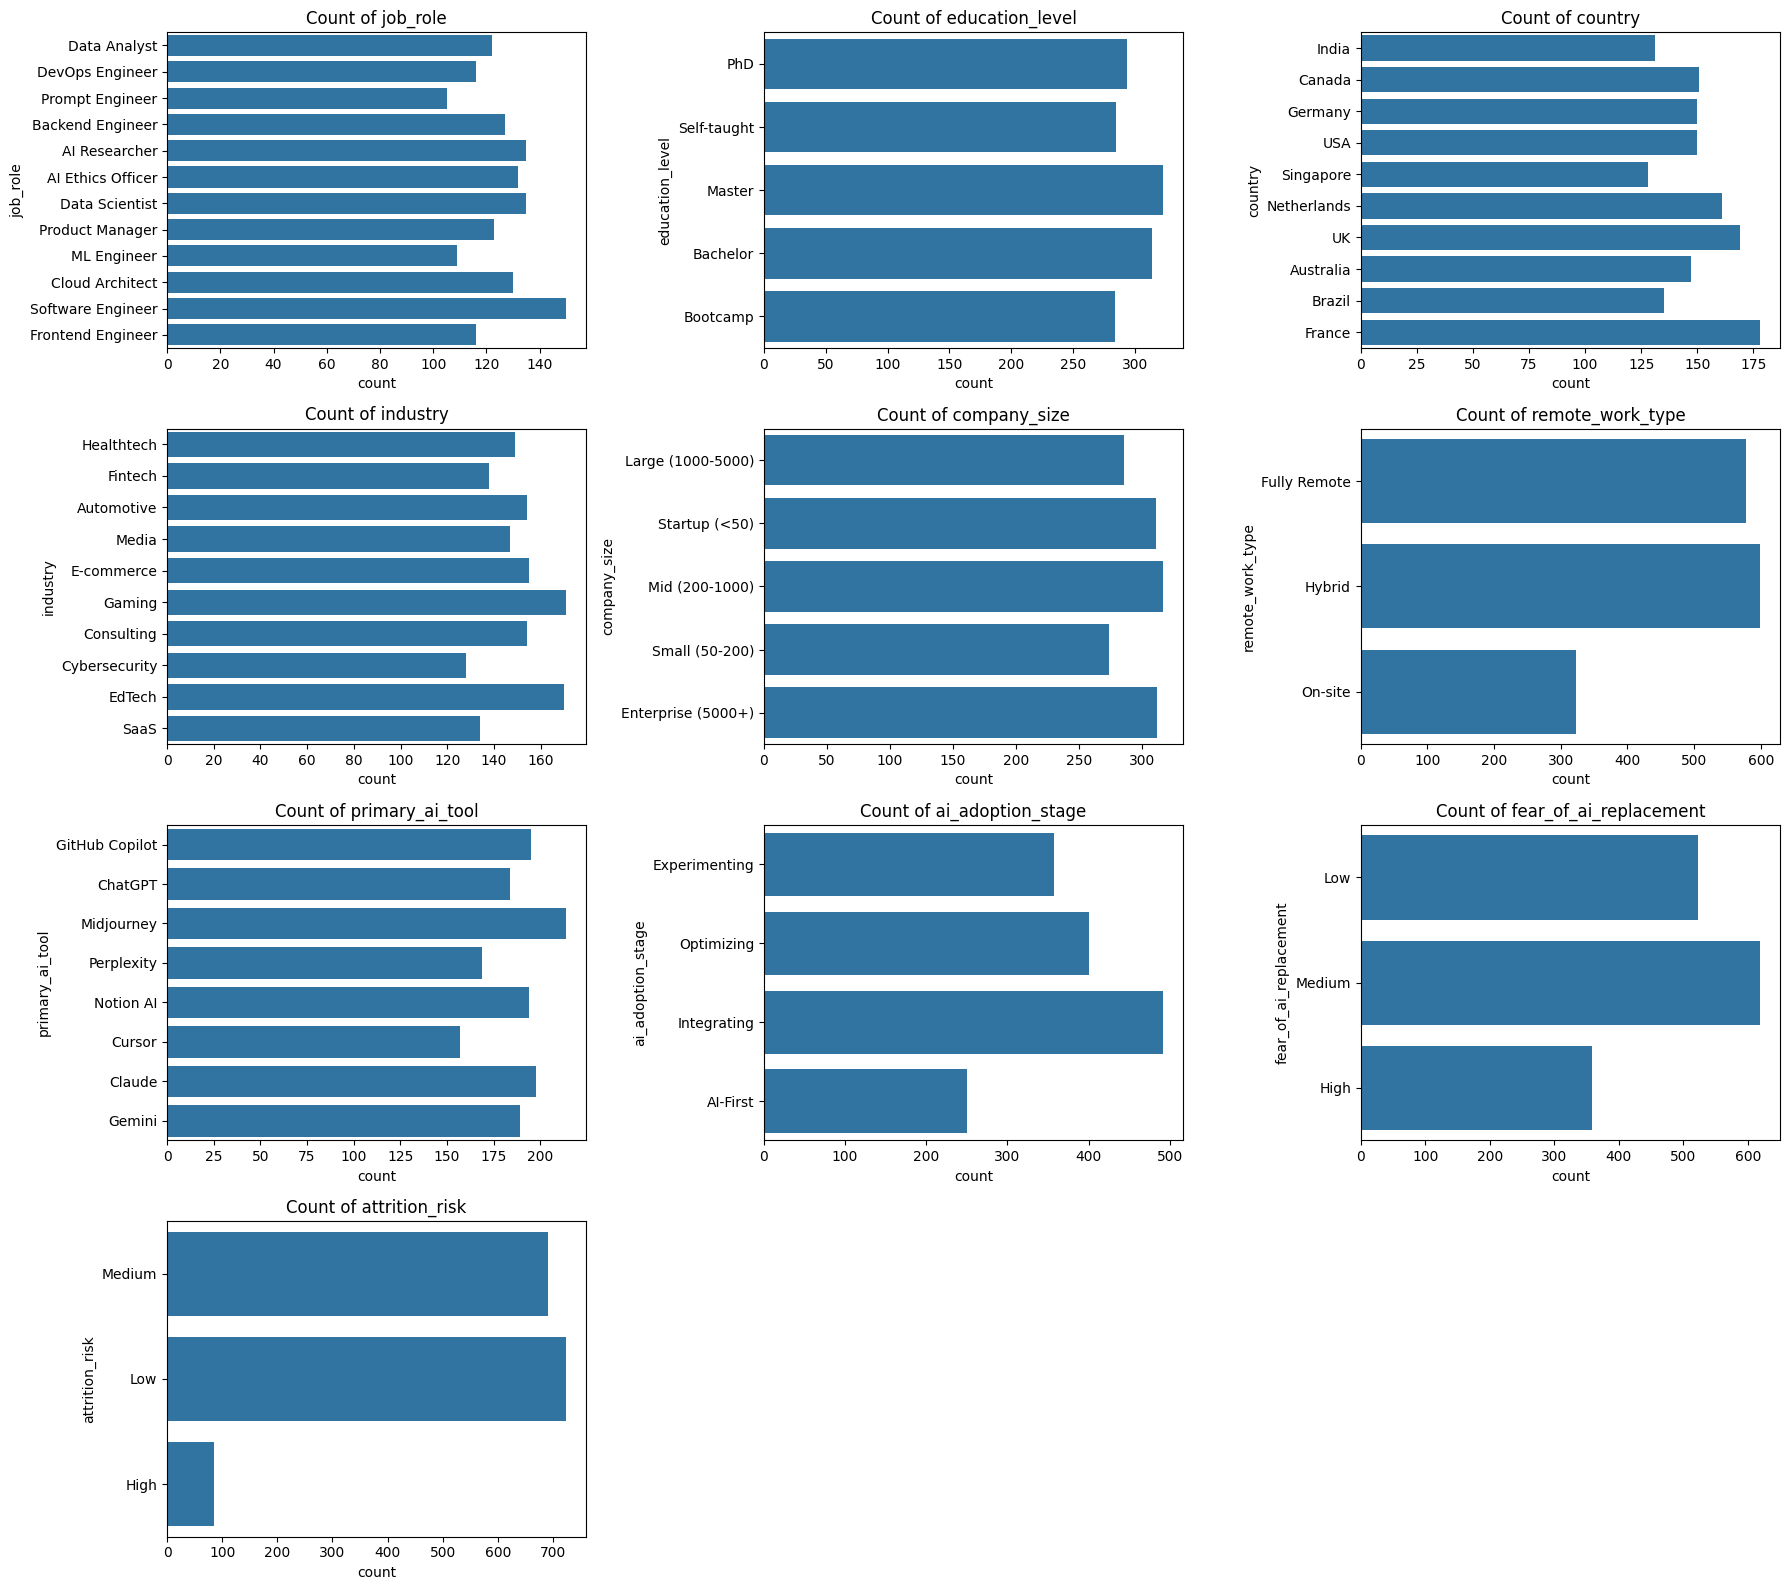

In [37]:
def show_cat_distribution(df, cols):
  n_cols = 3
  n_rows = (len(cols) + n_cols - 1) // n_cols

  plt.figure(figsize=(18, 4*n_rows))

  for i, col in enumerate(cols, 1):
      plt.subplot(n_rows, n_cols, i)
      sns.countplot(data=df, y=col)
      plt.title(f'Count of {col}')

  plt.tight_layout()
  plt.show()

all_cat_cols = df.select_dtypes(include=['object', 'category']).columns
show_cat_distribution(df, all_cat_cols)

## Normalisasi

In [38]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

std_math_cols = ['work_life_balance', 'burnout_productivity_ratio', 'burnout_squared', 'relative_burnout_industry']
base_std_cols = ['productivity_score', 'burnout_score', 'job_satisfaction_1_5']
std_cols =  base_std_cols + std_math_cols

base_minmax_cols = ['years_experience', 'team_size', 'salary_usd_k', 'ai_tools_used_per_day', 'hours_with_ai_assistance_daily', 'ai_replaces_my_tasks_pct', 'weekly_ai_upskilling_hrs']
minmax_cols = [col for col in (base_minmax_cols + math_cols) if col not in std_math_cols]

## Encoding

In [39]:
cat_cols = df.select_dtypes('object').columns
cat_cols

Index(['job_role', 'education_level', 'country', 'industry', 'company_size',
       'remote_work_type', 'primary_ai_tool', 'ai_adoption_stage',
       'fear_of_ai_replacement', 'attrition_risk'],
      dtype='object')

In [40]:
for col in cat_cols:
    print(f'{col}: {df[col].unique()}')

job_role: ['Data Analyst' 'DevOps Engineer' 'Prompt Engineer' 'Backend Engineer'
 'AI Researcher' 'AI Ethics Officer' 'Data Scientist' 'Product Manager'
 'ML Engineer' 'Cloud Architect' 'Software Engineer' 'Frontend Engineer']
education_level: ['PhD' 'Self-taught' 'Master' 'Bachelor' 'Bootcamp']
country: ['India' 'Canada' 'Germany' 'USA' 'Singapore' 'Netherlands' 'UK'
 'Australia' 'Brazil' 'France']
industry: ['Healthtech' 'Fintech' 'Automotive' 'Media' 'E-commerce' 'Gaming'
 'Consulting' 'Cybersecurity' 'EdTech' 'SaaS']
company_size: ['Large (1000-5000)' 'Startup (<50)' 'Mid (200-1000)' 'Small (50-200)'
 'Enterprise (5000+)']
remote_work_type: ['Fully Remote' 'Hybrid' 'On-site']
primary_ai_tool: ['GitHub Copilot' 'ChatGPT' 'Midjourney' 'Perplexity' 'Notion AI' 'Cursor'
 'Claude' 'Gemini']
ai_adoption_stage: ['Experimenting' 'Optimizing' 'Integrating' 'AI-First']
fear_of_ai_replacement: ['Low' 'Medium' 'High']
attrition_risk: ['Medium' 'Low' 'High']


### Ordinal

In [41]:
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

education_mapping = ['Self-taught', 'Bootcamp', 'Bachelor', 'Master', 'PhD']

company_size_mapping = ['Startup (<50)', 'Small (50-200)', 'Mid (200-1000)', 'Large (1000-5000)', 'Enterprise (5000+)']

ai_adoption_mapping = ['Experimenting', 'Optimizing', 'Integrating', 'AI-First']

fear_mapping = ['Low', 'Medium', 'High']

ordinal_cols = [
    'education_level',
    'company_size',
    'ai_adoption_stage',
    'fear_of_ai_replacement',
]

ordinal_cols_mapping = [
    education_mapping,
    company_size_mapping,
    ai_adoption_mapping,
    fear_mapping,
]

In [42]:
df['attrition_risk'] = df['attrition_risk'].map(target_mapping)
ord_enc = OrdinalEncoder(categories=ordinal_cols_mapping)

### Nominal

In [43]:
ohe_cols = [
    'job_role',
    'country',
    'industry',
    'remote_work_type',
    'primary_ai_tool'
]

In [44]:
ohe_enc = OneHotEncoder(drop='first')

## Balancing Data

In [45]:
smote = SMOTE(random_state=42)

# Data Splitting

In [46]:
X = df.drop(['attrition_risk', 'attrition_risk'], axis=1)
y = df['attrition_risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Feature Engineering 2

In [47]:
rf_selector = SelectFromModel(
    XGBClassifier(random_state=42, n_jobs=-1),
    threshold="median"
)

In [48]:
def getPrepo(wScale = True, wMathTune = True):

    std_final_cols = std_cols if wMathTune else base_std_cols
    minmax_final_cols = minmax_cols if wMathTune else base_minmax_cols
    
    prepo_w_scaler = ColumnTransformer([
        ('std_scaler', std_scaler, std_final_cols),
        ('minmax_scaler', minmax_scaler, minmax_final_cols),
        ('ordinal', ord_enc, ordinal_cols),
        ('ohe', ohe_enc, ohe_cols)
    ])
    
    prepo_wo_scaler = ColumnTransformer([
        ('std_passthrough', 'passthrough', std_final_cols),     
        ('minmax_passthrough', 'passthrough', minmax_final_cols),
        ('ordinal', ord_enc, ordinal_cols),
        ('ohe', ohe_enc, ohe_cols)
    ])

    if wScale: return prepo_w_scaler
    else: return prepo_wo_scaler

In [49]:
def getPipeline(model, wScale = True, wSmote = True, wMathTune = True):
  prepo = getPrepo(wScale, wMathTune)
  step_smote = smote if wSmote else None
  feature_tunning = math_tunning if wMathTune else None

  pipeline = ImbPipeline([
      ('math_tunning', feature_tunning),
      ('prepo', prepo),
      ('smote', step_smote),
      ('feature_selection', rf_selector),
      ('model', model)
  ])

  return pipeline

# Hyperparameter Tunning & Modelling

## Base

### Helper

In [50]:
def objective_base_rf(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'max_depth': trial.suggest_int('max_depth', 5, 50),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
      'random_state': 42
  }

  model = RandomForestClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [51]:
def objective_base_xgb(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'max_depth': trial.suggest_int('max_depth', 3, 10), # Jangan terlalu dalam
      'subsample': trial.suggest_float('subsample', 0.5, 1.0), # Mencegah overfitting
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'random_state': 42,
      'tree_method': 'hist',
      'device': 'cuda',
      'n_jobs': -1,
  }

  model = XGBClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [52]:
def objective_base_lgbm(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'num_leaves': trial.suggest_int('num_leaves', 20, 100),
      'max_depth': trial.suggest_int('max_depth', 3, 12),
      'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
      'subsample': trial.suggest_float('subsample', 0.5, 1.0),
      'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
      'random_state': 42,
      'verbose': -1,
      'n_jobs': -1,
      'device': 'gpu'
  }

  model = LGBMClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [53]:
def objective_base_catboost(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'iterations': trial.suggest_int('iterations', 100, 1000),
      'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
      'depth': trial.suggest_int('depth', 4, 10),
      'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
      'random_state': 42,
      'verbose': False,
      'task_type': 'GPU'
  }

  model = CatBoostClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [54]:
def objective_base_et(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
      'max_depth': trial.suggest_int('max_depth', 5, 50),
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
      'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
      'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
      'random_state': 42,
      'n_jobs': -1
  }

  model = ExtraTreesClassifier(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [55]:
def objective_base_logres(trial, wScale = True, wSmote = True, wMathTune = True):
  param = {
      'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
      'max_iter': 1000,
      'random_state': 42
  }

  model = LogisticRegression(**param)
  pipeline = getPipeline(model, wScale, wSmote, wMathTune)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [56]:
def show_best_model_metrics(pipeline, title, X=None, y=None):
    if X is None:
        X = X_train
    if y is None:
        y = y_train
        
    print('\n' + '='*65)
    print(f'📊 EVALUATION METRICS: {title}')
    print('='*65)
    
    pipeline.fit(X, y)
    y_pred_train = pipeline.predict(X)
    print("\n[ TRAINING DATA REPORT ]")
    print(classification_report(y, y_pred_train, digits=4))
    
    print("\n[ CROSS-VALIDATION (TEST) REPORT ]")
    y_pred_cv = cross_val_predict(pipeline, X, y, cv=3)
    print(classification_report(y, y_pred_cv, digits=4))
    print('-'*65)

In [57]:
def show_metric(algo_name, wScale, wSmote, wMathTune, params_current):
    
    if algo_name == 'Random Forest':
        current_model = RandomForestClassifier(**params_current, random_state=42, n_jobs=-1)
    elif algo_name == 'XGBoost':
        current_model = XGBClassifier(**params_current, random_state=42, tree_method='hist', device='cuda', n_jobs=-1)
    elif algo_name == 'LightGBM':
        current_model = LGBMClassifier(**params_current, random_state=42, verbose=-1, device='gpu')
    elif algo_name == 'CatBoost':
        current_model = CatBoostClassifier(**params_current, random_state=42, verbose=False, task_type='GPU')
    elif algo_name == 'Extra Trees':
        current_model = ExtraTreesClassifier(**params_current, random_state=42, n_jobs=-1)
    else:
        current_model = LogisticRegression(**params_current, random_state=42, max_iter=1000)

    current_prepo = getPrepo(wScale, wMathTune)
    current_smote = smote if wSmote else None

    pipeline_eval = getPipeline(current_model, wScale, wSmote, wMathTune)

    graph_title = f"{algo_name} (Scale: {wScale}, SMOTE: {wSmote}, Feature Extraction: {wMathTune})"
    show_best_model_metrics(pipeline_eval, graph_title)

### Execute

In [58]:
best_base = {}
objective_fn_base = {
    'Random Forest' : objective_base_rf,
    'XGBoost' : objective_base_xgb,
    'Logistic Regression' : objective_base_logres,
    'CatBoost' : objective_base_catboost,
    'LightGBM' : objective_base_lgbm,
    'Extra Trees' : objective_base_et,
}

#### RF

In [59]:
algo_name = 'Random Forest'
wMathTune = False
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter Random Forest terbaik
Scale: True, Smote: False, Feature Extraction: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 685, 'max_depth': 20, 'min_samples_split': 5, 'min_samples_leaf': 1}
F1-Score: 0.7615411351003041

📊 EVALUATION METRICS: Random Forest (Scale: True, SMOTE: False, Feature Extraction: False)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9781    0.9684    0.9732       507
           1     0.9633    0.9773    0.9703       484
           2     1.0000    0.9661    0.9828        59

    accuracy                         0.9724      1050
   macro avg     0.9805    0.9706    0.9754      1050
weighted avg     0.9725    0.9724    0.9724      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8952    0.8757    0.8853       507
           1     0.8137    0.8843    0.8475       484
           2     0.8571    0.4068    0.5517        59



In [60]:
algo_name = 'Random Forest'
wMathTune = True
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter Random Forest terbaik
Scale: True, Smote: False, Feature Extraction: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 767, 'max_depth': 12, 'min_samples_split': 5, 'min_samples_leaf': 1}
F1-Score: 0.727417505550351

📊 EVALUATION METRICS: Random Forest (Scale: True, SMOTE: False, Feature Extraction: True)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9960    0.9862    0.9911       507
           1     0.9817    0.9959    0.9887       484
           2     1.0000    0.9661    0.9828        59

    accuracy                         0.9895      1050
   macro avg     0.9926    0.9827    0.9875      1050
weighted avg     0.9896    0.9895    0.9895      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8767    0.8698    0.8733       507
           1     0.7996    0.8574    0.8275       484
           2     0.7500    0.3559    0.4828        59

   

#### XGB

In [61]:
algo_name = 'XGBoost'
wMathTune = False
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter XGBoost terbaik
Scale: True, Smote: False, Feature Extraction: False
Hyperparameter terbaik ditemukan!
{'n_estimators': 745, 'learning_rate': 0.006750979812709612, 'max_depth': 4, 'subsample': 0.8677653479224265, 'colsample_bytree': 0.98307832077612}
F1-Score: 0.7960993782636594

📊 EVALUATION METRICS: XGBoost (Scale: True, SMOTE: False, Feature Extraction: False)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9350    0.9073    0.9209       507
           1     0.8856    0.9277    0.9062       484
           2     0.9412    0.8136    0.8727        59

    accuracy                         0.9114      1050
   macro avg     0.9206    0.8828    0.8999      1050
weighted avg     0.9126    0.9114    0.9114      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8990    0.8777    0.8882       507
           1     0.8313    0.8657    0.8482       484
     

In [62]:
algo_name = 'XGBoost'
wMathTune = True
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter XGBoost terbaik
Scale: True, Smote: False, Feature Extraction: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 828, 'learning_rate': 0.0056828375585122656, 'max_depth': 3, 'subsample': 0.8421165132560784, 'colsample_bytree': 0.7200762468698007}
F1-Score: 0.7881972289316788

📊 EVALUATION METRICS: XGBoost (Scale: True, SMOTE: False, Feature Extraction: True)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9276    0.9093    0.9183       507
           1     0.8810    0.9174    0.8988       484
           2     0.9184    0.7627    0.8333        59

    accuracy                         0.9048      1050
   macro avg     0.9090    0.8631    0.8835      1050
weighted avg     0.9056    0.9048    0.9045      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8851    0.8817    0.8834       507
           1     0.8297    0.8554    0.8423       484
    

#### LR

In [63]:
algo_name = 'Logistic Regression'
wMathTune = False
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter Logistic Regression terbaik
Scale: True, Smote: False, Feature Extraction: False
Hyperparameter terbaik ditemukan!
{'C': 3.137936174424124, 'solver': 'lbfgs'}
F1-Score: 0.7404523711764764

📊 EVALUATION METRICS: Logistic Regression (Scale: True, SMOTE: False, Feature Extraction: False)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.8198    0.8343    0.8270       507
           1     0.7816    0.7913    0.7864       484
           2     0.8182    0.6102    0.6990        59

    accuracy                         0.8019      1050
   macro avg     0.8065    0.7453    0.7708      1050
weighted avg     0.8021    0.8019    0.8011      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8130    0.8146    0.8138       507
           1     0.7596    0.7769    0.7681       484
           2     0.7234    0.5763    0.6415        59

    accuracy                  

In [64]:
algo_name = 'Logistic Regression'
wMathTune = True
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter Logistic Regression terbaik
Scale: True, Smote: False, Feature Extraction: True
Hyperparameter terbaik ditemukan!
{'C': 9.41059378936611, 'solver': 'lbfgs'}
F1-Score: 0.7084141925542161

📊 EVALUATION METRICS: Logistic Regression (Scale: True, SMOTE: False, Feature Extraction: True)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.8409    0.8442    0.8425       507
           1     0.8016    0.8182    0.8098       484
           2     0.8511    0.6780    0.7547        59

    accuracy                         0.8229      1050
   macro avg     0.8312    0.7801    0.8024      1050
weighted avg     0.8233    0.8229    0.8225      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8267    0.8185    0.8226       507
           1     0.7544    0.7934    0.7734       484
           2     0.6667    0.4407    0.5306        59

    accuracy                     

#### CB

In [65]:
algo_name = 'CatBoost'
wMathTune = False
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune,
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter CatBoost terbaik
Scale: True, Smote: False, Feature Extraction: False
Hyperparameter terbaik ditemukan!
{'iterations': 550, 'learning_rate': 0.03728579648244504, 'depth': 4, 'l2_leaf_reg': 9.977498958270612}
F1-Score: 0.8019585750402407

📊 EVALUATION METRICS: CatBoost (Scale: True, SMOTE: False, Feature Extraction: False)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9178    0.9034    0.9105       507
           1     0.8680    0.8967    0.8821       484
           2     0.8235    0.7119    0.7636        59

    accuracy                         0.8895      1050
   macro avg     0.8698    0.8373    0.8521      1050
weighted avg     0.8896    0.8895    0.8892      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8982    0.8876    0.8929       507
           1     0.8410    0.8636    0.8522       484
           2     0.7115    0.6271    0.6667    

In [66]:
algo_name = 'CatBoost'
wMathTune = True
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune,
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter CatBoost terbaik
Scale: True, Smote: False, Feature Extraction: True
Hyperparameter terbaik ditemukan!
{'iterations': 729, 'learning_rate': 0.004795123848857678, 'depth': 7, 'l2_leaf_reg': 5.304238455407948}
F1-Score: 0.7949637481130295

📊 EVALUATION METRICS: CatBoost (Scale: True, SMOTE: False, Feature Extraction: True)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9273    0.9053    0.9162       507
           1     0.8810    0.9174    0.8988       484
           2     0.9216    0.7966    0.8545        59

    accuracy                         0.9048      1050
   macro avg     0.9099    0.8731    0.8898      1050
weighted avg     0.9056    0.9048    0.9047      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8933    0.8915    0.8924       507
           1     0.8394    0.8636    0.8513       484
           2     0.7391    0.5763    0.6476     

#### LGBM

In [67]:
algo_name = 'LightGBM'
wMathTune = False
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
best_base[algo_name] = []
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter LightGBM terbaik
Scale: True, Smote: False, Feature Extraction: False


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

Hyperparameter terbaik ditemukan!
{'n_estimators': 730, 'learning_rate': 0.005212158124584939, 'num_leaves': 53, 'max_depth': 3, 'min_child_samples': 49, 'subsample': 0.9743301047565935, 'colsample_bytree': 0.9335485661395405}
F1-Score: 0.8121899665535408

📊 EVALUATION METRICS: LightGBM (Scale: True, SMOTE: False, Feature Extraction: False)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     0.9256    0.8836    0.9041       507
           1     0.8496    0.8988    0.8735       484
           2     0.7593    0.6949    0.7257        59

    accuracy                         0.8800      1050
   macro avg     0.8448    0.8258    0.8344      1050
weighted avg     0.8812    0.8800    0.8800      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8944    0.8856    0.8900       507
           1     0.8424    0.8616    0.8519       484
           2     0.7358    0.6610    0.6964        

In [68]:
algo_name = 'LightGBM'
wMathTune = True
fn_objective = objective_fn_base[algo_name]
print(f'Mencari hyperparameter {algo_name} terbaik')
for i in range(3):
    wScale = False if i == 1 else True
    wSmote = False if i == 0 else True
    print(f'Scale: {wScale}, Smote: {wSmote}, Feature Extraction: {wMathTune}')

    const_sampler = TPESampler(seed=42)
    study = optuna.create_study(direction='maximize', sampler=const_sampler)
    study.optimize(lambda trial: fn_objective(trial, wScale, wSmote, wMathTune), n_trials=80)

    print('Hyperparameter terbaik ditemukan!')
    print(study.best_params)
    print(f'F1-Score: {study.best_value}')

    best_base[algo_name].append({
        'param': study.best_params,
        'f1_score': study.best_value,
        'wScale': wScale,
        'wSmote': wSmote,
        'wMathTune': wMathTune
    })
    show_metric(algo_name, wScale, wSmote, wMathTune, study.best_params)

Mencari hyperparameter LightGBM terbaik
Scale: True, Smote: False, Feature Extraction: True
Hyperparameter terbaik ditemukan!
{'n_estimators': 485, 'learning_rate': 0.04944540251747687, 'num_leaves': 52, 'max_depth': 7, 'min_child_samples': 26, 'subsample': 0.8104305068003272, 'colsample_bytree': 0.8985069894179922}
F1-Score: 0.7931160999176319

📊 EVALUATION METRICS: LightGBM (Scale: True, SMOTE: False, Feature Extraction: True)

[ TRAINING DATA REPORT ]
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       507
           1     1.0000    1.0000    1.0000       484
           2     1.0000    1.0000    1.0000        59

    accuracy                         1.0000      1050
   macro avg     1.0000    1.0000    1.0000      1050
weighted avg     1.0000    1.0000    1.0000      1050


[ CROSS-VALIDATION (TEST) REPORT ]
              precision    recall  f1-score   support

           0     0.8708    0.8777    0.8743       507
           1   

### Recap

In [69]:
rekap_hasil = []

for algo_name, skenario_list in best_base.items():
    for hasil in skenario_list:
        rekap_hasil.append({
            'Tahap': '1. Base Model (Lvl 0)',
            'Algoritma': algo_name,
            'Scaling': '✅' if hasil['wScale'] else '❌',
            'SMOTE': '✅' if hasil['wSmote'] else '❌',
            'Feature Extraction': '✅' if hasil['wMathTune'] else '❌',
            'F1_Macro_Score': hasil['f1_score'],
            'Best_Parameters': str(hasil['param'])
        })

df_rekap = pd.DataFrame(rekap_hasil)

df_rekap = df_rekap.sort_values(by=['Tahap', 'F1_Macro_Score'], ascending=[True, False]).reset_index(drop=True)

display(df_rekap)

,Tahap,Algoritma,Scaling,SMOTE,Feature Extraction,F1_Macro_Score,Best_Parameters
0,1. Base Model (Lvl 0),Random Forest,❌,✅,❌,0.823741,"{'n_estimators': 101, 'max_depth': 31, 'min_sa..."
1,1. Base Model (Lvl 0),CatBoost,❌,✅,❌,0.820456,"{'iterations': 247, 'learning_rate': 0.0361724..."
2,1. Base Model (Lvl 0),CatBoost,✅,✅,❌,0.816776,"{'iterations': 848, 'learning_rate': 0.0035472..."
3,1. Base Model (Lvl 0),CatBoost,✅,✅,✅,0.816423,"{'iterations': 238, 'learning_rate': 0.0020774..."
4,1. Base Model (Lvl 0),Random Forest,✅,✅,❌,0.816110,"{'n_estimators': 128, 'max_depth': 39, 'min_sa..."
5,1. Base Model (Lvl 0),LightGBM,✅,✅,❌,0.815009,"{'n_estimators': 558, 'learning_rate': 0.00171..."
6,1. Base Model (Lvl 0),Random Forest,❌,✅,✅,0.813744,"{'n_estimators': 349, 'max_depth': 49, 'min_sa..."
7,1. Base Model (Lvl 0),LightGBM,✅,❌,❌,0.812190,"{'n_estimators': 730, 'learning_rate': 0.00521..."
8,1. Base Model (Lvl 0),LightGBM,✅,✅,✅,0.812064,"{'n_estimators': 207, 'learning_rate': 0.00447..."
9,1. Base Model (Lvl 0),LightGBM,❌,✅,✅,0.810308,"{'n_estimators': 421, 'learning_rate': 0.00496..."


## MetaLearning

### Helper

In [70]:
def show_metric_meta(algo_name, wScale, wSmote, params_current):
    if algo_name == 'Logistic Regression':
        base_models_stack = [
            ('rf', RandomForestClassifier(**get_base_param('Random Forest'), random_state=42, n_jobs=-1)),
            ('xgb', XGBClassifier(**get_base_param('XGBoost'), random_state=42, tree_method='hist', device='cuda', n_jobs=-1)),
            ('logres', LogisticRegression(**get_base_param('Logistic Regression'), random_state=42, max_iter=1000)),
        ]
        final_estimator = LogisticRegression(**params_current, random_state=42, max_iter=1000)
    
    elif algo_name == 'Ridge Classifier':
        base_models_stack = [
            ('catboost', CatBoostClassifier(**get_base_param('CatBoost'), random_state=42, verbose=False, task_type='GPU')),
            ('lgbm', LGBMClassifier(**get_base_param('LightGBM'), random_state=42, verbose=-1, device='gpu')),
            ('et', ExtraTreesClassifier(**get_base_param('Extra Trees'), random_state=42, n_jobs=-1)),
        ]
        final_estimator = RidgeClassifier(**params_current, random_state=42)
    
    best_stacking_model = StackingClassifier(estimators=base_models_stack, final_estimator=final_estimator)

    pipeline_eval = getPipeline(best_stacking_model, wScale, wSmote)

    graph_title = f"Meta {algo_name} (Scale: {wScale}, SMOTE: {wSmote})"
    show_best_model_metrics(pipeline_eval, graph_title)

In [71]:
def objective_meta_logres(trial, wScale = True, wSmote = True):
  param = {
      'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
      'max_iter': 1000,
      'random_state': 42
  }

  if wScale and not wSmote:
        i = 0
  elif not wScale and wSmote:
        i = 1
  else:
        i = 2

  base = [
      ('rf', RandomForestClassifier(**best_base['Random Forest'][i]['param'], random_state=42)),
      ('xgb', XGBClassifier(**best_base['XGBoost'][i]['param'], random_state=42, tree_method='hist', device='cuda', n_jobs=-1)),
      ('logres', LogisticRegression(**best_base['Logistic Regression'][i]['param'], random_state=42, max_iter=1000)),
  ]

  lvl_1 = LogisticRegression(**param)

  stacking = StackingClassifier(estimators=base, final_estimator=lvl_1)

  pipeline = getPipeline(stacking, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [72]:
def objective_meta_ridge(trial, wScale = True, wSmote = True):
  param = {
      'alpha': trial.suggest_float('alpha', 0.1, 10.0, log=True),
      'solver': trial.suggest_categorical('solver', ['auto', 'svd', 'cholesky', 'sag']),
      'random_state': 42
  }

  if wScale and not wSmote:
        i = 0
  elif not wScale and wSmote:
        i = 1
  else:
        i = 2

  base = [
      ('catboost', CatBoostClassifier(**best_base['CatBoost'][i]['param'], random_state=42, verbose=False, task_type='GPU')),
      ('lgbm', LGBMClassifier(**best_base['LightGBM'][i]['param'], random_state=42, verbose=-1, device='gpu')),
      ('et', ExtraTreesClassifier(**best_base['Extra Trees'][i]['param'], random_state=42, n_jobs=-1)),
  ]

  lvl_1 = RidgeClassifier(**param)

  stacking = StackingClassifier(estimators=base, final_estimator=lvl_1)

  pipeline = getPipeline(stacking, wScale, wSmote)

  score = cross_val_score(pipeline, X_train, y_train, cv=3, scoring='f1_macro')

  return score.mean()

In [73]:
best_meta = {}
objective_fn_meta = {
    'Logistic Regression' : objective_meta_logres,
    'Ridge Classifier': objective_meta_ridge,
}